## Verificador de TRNG
---

**Análisis y Diseño de Algoritmos**

Proyecto 02: True Random Number Generators. 

<br>

Este notebook evalúa la calidad de los 160,000 enteros que produce su sistema. Combina tres pruebas estadísticas y una prueba visual:

1. **Chi cuadrado:** ¿los valores están repartidos de forma uniforme?
2. **Rachas:** ¿el orden en que aparecen los valores parece azaroso?
3. **Pares consecutivos:** ¿un valor da pistas sobre el siguiente?
4. **Visual:** ¿la imagen de 400 por 400 píxeles se ve como ruido puro?

**Cómo usarlo**

1. Pegue su arreglo de 160,000 enteros en la sección 1.
2. Ejecute todas las celdas (Run All).
3. Lea el resumen de la sección 6 y observe con cuidado la sección 5.

Este notebook es una brújula, no un certificado. Pasar las pruebas no demuestra que su fuente sea verdaderamente aleatoria, pero no pasarlas sí es evidencia de un problema que vale la pena entender y explicar en su presentación.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
AZUL = "#2a6fb0"
GRIS = "#6b7280"

## 1. Sus datos

Asigne su arreglo a la variable `datos`. Hay tres formas de hacerlo:

* **Pegar la lista:** `datos = [183, 12, 240, ...]`
* **Leer un archivo de texto** con un entero por línea: `datos = np.loadtxt("mis_datos.txt", dtype=np.int64)`
* **Usar una variable que ya tiene** en este notebook: `datos = mi_arreglo`

Declare también el rango teórico de su generador con `VALOR_MIN` y `VALOR_MAX`. Por ejemplo, si su sistema produce un byte, use `0` y `255`. Si los deja en `None`, el notebook los toma de sus datos y se lo advierte, pero eso puede esconder valores que su sistema nunca llega a producir.

Mientras `datos` tengan el valor `None`, el notebook corre en **modo demostración** con datos de prueba, para que pueda ver cómo funciona antes de usar los suyos.

In [2]:
datos = np.loadtxt("salida/corrida1.txt", dtype=np.int64)
VALOR_MIN = 0
VALOR_MAX = 255

In [3]:
N_ESPERADO = 160_000
LADO = 400
ALFA = 0.01

modo_demo = datos is None
if modo_demo:
    datos = np.random.default_rng().integers(0, 256, N_ESPERADO)
    VALOR_MIN, VALOR_MAX = 0, 255
    print("MODO DEMOSTRACIÓN: estos NO son sus datos.\n")

x = np.asarray(datos)
if x.ndim != 1:
    raise ValueError(f"Se esperaba un arreglo de una dimensión y llegó con forma {x.shape}.")
if len(x) != N_ESPERADO:
    raise ValueError(f"Se esperaban {N_ESPERADO:,} enteros y llegaron {len(x):,}.")
if x.dtype.kind == "f":
    if not np.all(np.isfinite(x)) or not np.all(x == np.floor(x)):
        raise ValueError("El arreglo tiene valores que no son enteros (o son NaN).")
elif x.dtype.kind not in "iu":
    raise ValueError(f"El arreglo debe contener enteros y llegó con tipo {x.dtype}.")
x = x.astype(np.int64)

if VALOR_MIN is None:
    VALOR_MIN = int(x.min())
    print(f"Aviso: VALOR_MIN no declarado, se usa el mínimo observado ({VALOR_MIN}).")
if VALOR_MAX is None:
    VALOR_MAX = int(x.max())
    print(f"Aviso: VALOR_MAX no declarado, se usa el máximo observado ({VALOR_MAX}).")
if x.min() < VALOR_MIN or x.max() > VALOR_MAX:
    raise ValueError(f"Hay valores fuera del rango declarado [{VALOR_MIN}, {VALOR_MAX}].")

K = VALOR_MAX - VALOR_MIN + 1
if K < 2:
    raise ValueError("El rango debe contener al menos dos valores distintos.")

distintos = len(np.unique(x))
print(f"Datos: {len(x):,} enteros")
print(f"Rango declarado: [{VALOR_MIN}, {VALOR_MAX}] ({K:,} valores posibles)")
print(f"Mínimo y máximo observados: {x.min()} y {x.max()}")
print(f"Valores distintos observados: {distintos:,}")
if K <= 100_000 and distintos < K:
    print(f"Aviso: {K - distintos:,} valores posibles nunca aparecieron.")

Datos: 160,000 enteros
Rango declarado: [0, 255] (256 valores posibles)
Mínimo y máximo observados: 0 y 255
Valores distintos observados: 256


In [4]:
resultados = {}

def asignar_bins(valores, k, n_bins):
    bordes = np.array([-(-(i * k) // n_bins) for i in range(n_bins + 1)], dtype=np.int64)
    indices = np.searchsorted(bordes, valores, side="right") - 1
    return indices, np.diff(bordes)

def veredicto(p, detectar_perfecto=False):
    if p < ALFA:
        return "NO PASA"
    if detectar_perfecto and p > 1 - ALFA:
        return "SOSPECHOSO"
    return "PASA"

Las tres pruebas usan un nivel de significancia de 0.01, y siempre se leen igual: el **p-valor** es la probabilidad de ver una desviación tan grande como la suya si su generador fuera perfecto.

* **p menor a 0.01:** la desviación es demasiado grande para ser casualidad. **NO PASA.**
* **p entre 0.01 y 0.99:** nada fuera de lo esperable. **PASA.**
* **p mayor a 0.99** (solo en las pruebas de chi cuadrado): los datos son *demasiado* regulares. Un generador azaroso también fluctúa. **SOSPECHOSO.**

## 2. Prueba 1: chi cuadrado de uniformidad

**Qué mide.** Cuenta cuántas veces apareció cada valor y lo compara con lo que se esperaría si todos fueran igual de probables. Si el rango tiene más de 256 valores, se agrupan en 256 intervalos de igual tamaño.

**Qué detecta.** Sesgos: valores que salen más que otros, rangos que casi nunca aparecen, un generador que se concentra en una zona.

**Qué no ve.** El orden. Un contador (0, 1, 2, 3...) que se repite pasa esta prueba perfectamente. Para eso están las pruebas 2 y 3.

Intervalos: 256   Frecuencia esperada por intervalo: 625.0
Estadístico chi cuadrado: 260.97   Grados de libertad: 255
p-valor: 0.3853
Veredicto: PASA


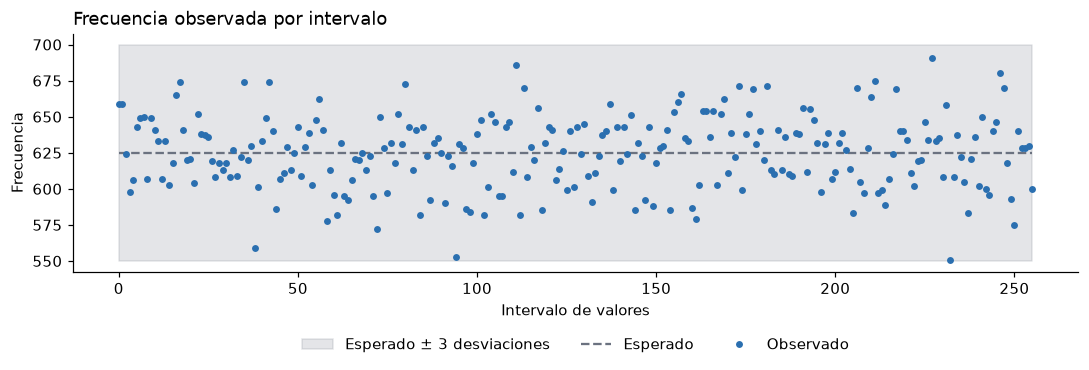

In [5]:
def prueba_chi_cuadrado(x, minimo, k):
    n_bins = min(k, 256)
    indices, anchos = asignar_bins(x - minimo, k, n_bins)
    observado = np.bincount(indices, minlength=n_bins)
    esperado = len(x) * anchos / k
    estadistico = ((observado - esperado) ** 2 / esperado).sum()
    gl = n_bins - 1
    p = stats.chi2.sf(estadistico, gl)
    return observado, esperado, estadistico, gl, p

obs, esp, chi2_est, chi2_gl, chi2_p = prueba_chi_cuadrado(x, VALOR_MIN, K)
v1 = veredicto(chi2_p, detectar_perfecto=True)
resultados["Chi cuadrado (uniformidad)"] = (chi2_est, chi2_gl, chi2_p, v1)

print(f"Intervalos: {len(obs)}   Frecuencia esperada por intervalo: {esp.mean():,.1f}")
print(f"Estadístico chi cuadrado: {chi2_est:,.2f}   Grados de libertad: {chi2_gl}")
print(f"p-valor: {chi2_p:.4f}")
print(f"Veredicto: {v1}")

sigma = np.sqrt(esp * (1 - esp / len(x)))
pos = np.arange(len(obs))
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.fill_between(pos, esp - 3 * sigma, esp + 3 * sigma, color=GRIS, alpha=0.18, label="Esperado ± 3 desviaciones")
ax.plot(pos, esp, color=GRIS, lw=1.5, ls="--", label="Esperado")
ax.plot(pos, obs, "o", color=AZUL, ms=3.5, label="Observado")
ax.set_xlabel("Intervalo de valores")
ax.set_ylabel("Frecuencia")
ax.set_title("Frecuencia observada por intervalo", loc="left")
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.22))
plt.tight_layout()
plt.show()

**Cómo leer la gráfica.** Los puntos azules deberían moverse al azar alrededor de la línea punteada, casi siempre dentro de la banda gris. Pocos puntos fuera de la banda son normales; muchos, o una forma clara (una colina, una pendiente, un hueco), indican sesgo.

## 3. Prueba 2: rachas

**Qué mide.** Marca cada valor como "alto" (por encima del centro del rango) o "bajo" y cuenta las **rachas**, que son tramos seguidos del mismo tipo. En una secuencia azarosa el número de rachas está muy bien determinado. Si hay muy pocas, el generador se queda pegado en una zona. Si hay demasiadas, alterna de forma artificial.

**Qué detecta.** Dependencia en el orden: memoria, deriva lenta, oscilaciones.

**Qué no ve.** Sesgos de distribución que no cambian el orden relativo de alto y bajo.

Valores altos: 80,268   Valores bajos: 79,732
Rachas observadas: 79,913   Rachas esperadas: 80,000.1
Estadístico z: -0.436
p-valor: 0.6632
Veredicto: PASA


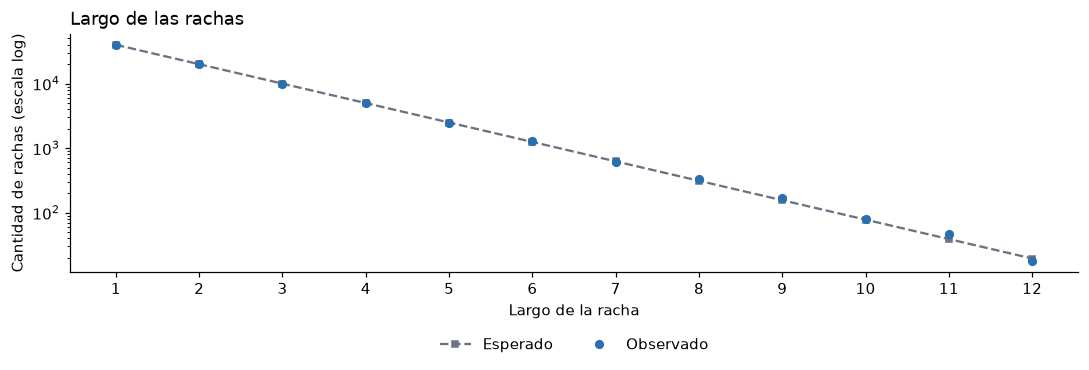

In [6]:
def prueba_rachas(x, minimo, k):
    umbral = minimo + (k - 1) / 2
    alto = x > umbral
    n1 = int(alto.sum())
    n2 = len(x) - n1
    if n1 == 0 or n2 == 0:
        return None
    n = n1 + n2
    cortes = np.flatnonzero(alto[1:] != alto[:-1])
    rachas = len(cortes) + 1
    largos = np.diff(np.concatenate(([-1], cortes, [n - 1])))
    media = 2 * n1 * n2 / n + 1
    varianza = 2 * n1 * n2 * (2 * n1 * n2 - n) / (n ** 2 * (n - 1))
    z = (rachas - media) / np.sqrt(varianza)
    p = 2 * stats.norm.sf(abs(z))
    return n1, n2, rachas, media, z, p, largos

salida = prueba_rachas(x, VALOR_MIN, K)
if salida is None:
    resultados["Rachas (orden)"] = (float("nan"), None, 0.0, "NO PASA")
    print("Todos los valores quedaron del mismo lado del centro del rango. NO PASA.")
else:
    n1, n2, rachas, r_media, r_z, r_p, largos = salida
    v2 = veredicto(r_p)
    resultados["Rachas (orden)"] = (r_z, None, r_p, v2)
    print(f"Valores altos: {n1:,}   Valores bajos: {n2:,}")
    print(f"Rachas observadas: {rachas:,}   Rachas esperadas: {r_media:,.1f}")
    print(f"Estadístico z: {r_z:.3f}")
    print(f"p-valor: {r_p:.4f}")
    print(f"Veredicto: {v2}")

    p_alto = n1 / (n1 + n2)
    cortos = np.arange(1, 13)
    esperado_largos = (rachas / 2) * (p_alto ** (cortos - 1) * (1 - p_alto) + (1 - p_alto) ** (cortos - 1) * p_alto)
    observado_largos = np.array([(largos == L).sum() for L in cortos])
    fig, ax = plt.subplots(figsize=(10, 3.6))
    ax.plot(cortos, esperado_largos, color=GRIS, lw=1.5, ls="--", marker="s", ms=4, label="Esperado")
    ax.plot(cortos, observado_largos, "o", color=AZUL, ms=5, label="Observado")
    ax.set_yscale("log")
    ax.set_xticks(cortos)
    ax.set_xlabel("Largo de la racha")
    ax.set_ylabel("Cantidad de rachas (escala log)")
    ax.set_title("Largo de las rachas", loc="left")
    ax.legend(frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.22))
    plt.tight_layout()
    plt.show()

**Cómo leer la gráfica.** Los puntos azules deberían caer sobre la línea punteada. Si faltan rachas largas, su generador cambia de lado con demasiada frecuencia. Si sobran, se queda pegado.

## 4. Prueba 3: pares consecutivos

**Qué mide.** Toma los valores de dos en dos, (x₁, x₂), (x₃, x₄), ..., y revisa si todas las combinaciones de "nivel del primero" con "nivel del segundo" aparecen con la frecuencia que les corresponde. Los valores se agrupan en 16 niveles, lo que da 256 combinaciones posibles.

**Qué detecta.** Que un valor condicione al siguiente. Es la prueba que atrapa a los generadores deterministas simples, que pueden pasar las dos pruebas anteriores.

In [7]:
def prueba_pares(x, minimo, k):
    niveles = min(k, 16)
    indices, anchos = asignar_bins(x - minimo, k, niveles)
    primero = indices[0::2]
    segundo = indices[1::2]
    observado = np.bincount(primero * niveles + segundo, minlength=niveles ** 2)
    prob = anchos / k
    esperado = len(primero) * np.outer(prob, prob).ravel()
    estadistico = ((observado - esperado) ** 2 / esperado).sum()
    gl = niveles ** 2 - 1
    p = stats.chi2.sf(estadistico, gl)
    return niveles, observado, esperado, estadistico, gl, p

niveles, obs_p, esp_p, par_est, par_gl, par_p = prueba_pares(x, VALOR_MIN, K)
v3 = veredicto(par_p, detectar_perfecto=True)
resultados["Pares consecutivos"] = (par_est, par_gl, par_p, v3)

print(f"Niveles: {niveles}   Combinaciones: {niveles ** 2}   Frecuencia esperada por combinación: {esp_p.mean():,.1f}")
print(f"Estadístico chi cuadrado: {par_est:,.2f}   Grados de libertad: {par_gl}")
print(f"p-valor: {par_p:.4f}")
print(f"Veredicto: {v3}")

Niveles: 16   Combinaciones: 256   Frecuencia esperada por combinación: 312.5
Estadístico chi cuadrado: 272.91   Grados de libertad: 255
p-valor: 0.2105
Veredicto: PASA


## 5. Prueba visual

Los 160,000 enteros se convierten en una imagen de 400 por 400 píxeles en escala de grises, llenando fila por fila: el valor mínimo de su rango es negro, el máximo es blanco. Junto a ella aparece una imagen de referencia generada con un buen generador pseudoaleatorio sobre el mismo rango, para que compare.

Mire la imagen con calma antes de seguir.

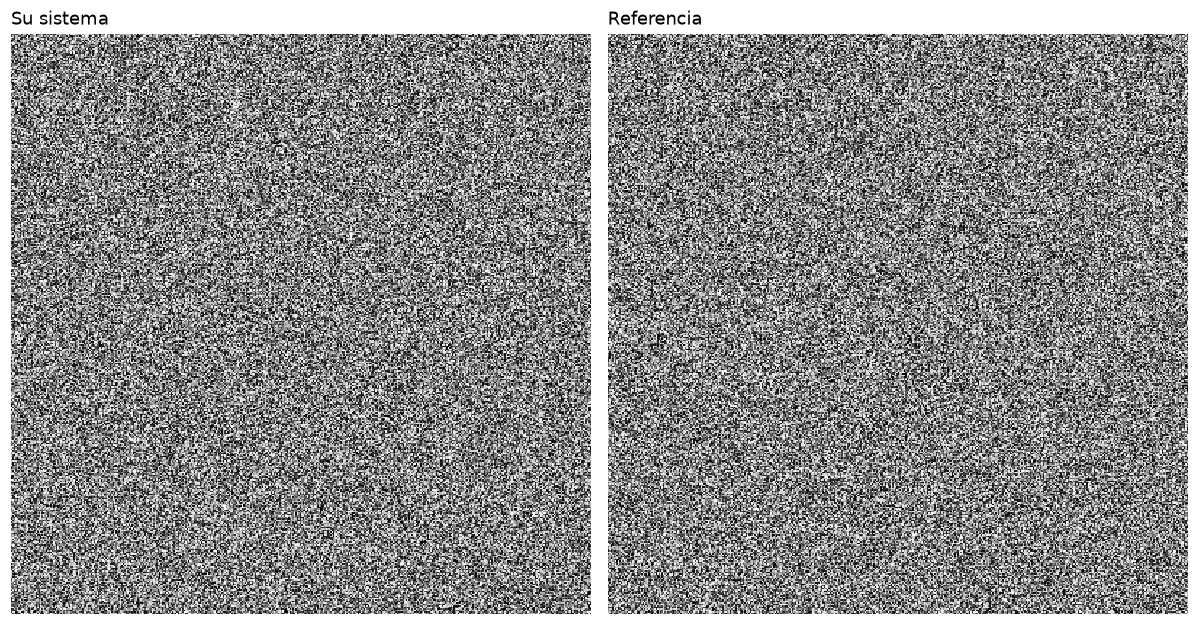

In [8]:
def a_imagen(valores, minimo, k):
    grises = np.rint((valores - minimo) * 255 / (k - 1))
    return grises.astype(np.uint8).reshape(LADO, LADO)

referencia = np.random.default_rng().integers(VALOR_MIN, VALOR_MAX + 1, N_ESPERADO)

fig, ejes = plt.subplots(1, 2, figsize=(11, 5.6))
for eje, valores, titulo in ((ejes[0], x, "Su sistema"), (ejes[1], referencia, "Referencia")):
    eje.imshow(a_imagen(valores, VALOR_MIN, K), cmap="gray", vmin=0, vmax=255, interpolation="nearest")
    eje.set_title(titulo, loc="left")
    eje.axis("off")
plt.tight_layout()
plt.show()

**Qué debería ver.** Ruido uniforme, como la nieve de un televisor sin señal: sin estructura a ninguna escala, sin zonas más claras u oscuras que otras.

**Qué indica un problema**

* **Bandas horizontales o verticales:** patrones que se repiten con un período cercano a 400 o a un divisor de 400.
* **Diagonales:** un período cercano a 400, que se va desfasando fila tras fila.
* **Bloques o cuadros repetidos:** el generador está recorriendo un ciclo corto.
* **Zonas claras u oscuras extensas, o un degradado:** deriva o sesgo; el sistema se queda pegado o se mueve lentamente.
* **Imagen casi toda de un tono:** los valores se concentran en una parte del rango.
* **Textura demasiado regular o con cuadrícula:** el orden es sospechosamente perfecto.

Si ve algo extraño, la posición en el arreglo de un píxel de la fila `f` y la columna `c` es `f * 400 + c`. Úsela para volver a sus datos y averiguar qué pasaba en su sistema en ese momento.

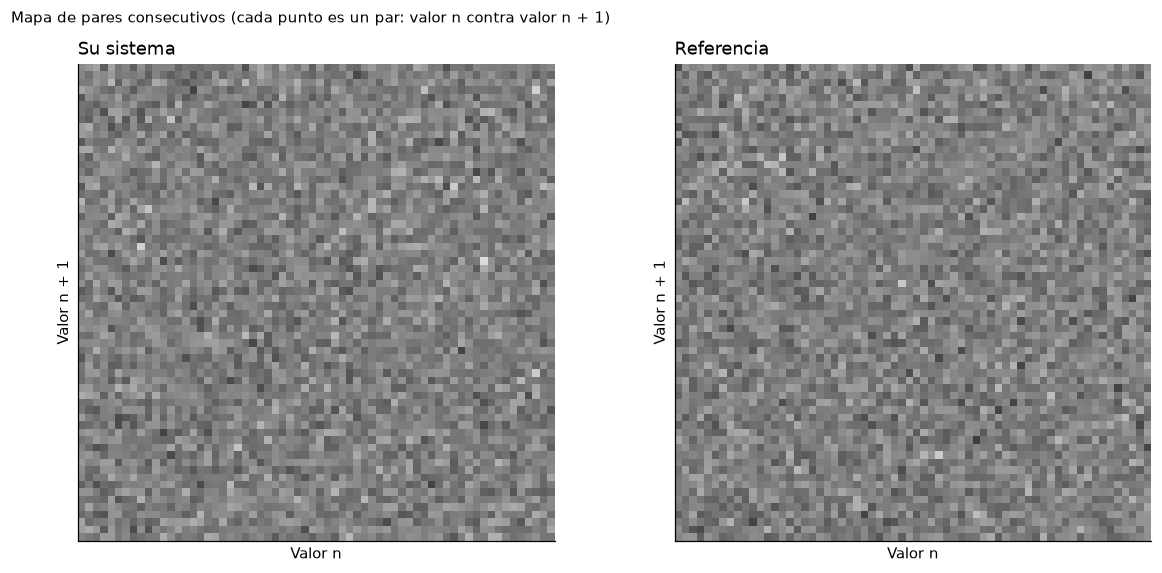

In [9]:
L = min(K, 64)
rango = [[VALOR_MIN, VALOR_MAX + 1]] * 2

fig, ejes = plt.subplots(1, 2, figsize=(11, 5.2))
for eje, valores, titulo in ((ejes[0], x, "Su sistema"), (ejes[1], referencia, "Referencia")):
    mapa, _, _ = np.histogram2d(valores[:-1], valores[1:], bins=L, range=rango)
    eje.imshow(mapa.T, cmap="gray", vmin=0, vmax=2 * mapa.mean(), origin="lower", interpolation="nearest")
    eje.set_title(titulo, loc="left")
    eje.set_xlabel("Valor n")
    eje.set_ylabel("Valor n + 1")
    eje.set_xticks([])
    eje.set_yticks([])
fig.suptitle("Mapa de pares consecutivos (cada punto es un par: valor n contra valor n + 1)", x=0.01, ha="left", fontsize=10)
plt.tight_layout()
plt.show()

**Cómo leer el mapa.** Cada celda cuenta cuántas veces un valor fue seguido por otro. Un buen generador llena todo el cuadrado con un gris parejo. Líneas, rejillas, huecos o zonas vacías significan que unos valores sí determinan a los que les siguen.

**Su observación.** Doble clic en esta celda para editarla. Describa en dos o tres líneas lo que ve en la imagen y en el mapa de pares, y si coincide o no con lo que encontraron las pruebas estadísticas.

## 6. Resumen

In [10]:
print(f"{'Prueba':<30}{'Estadístico':>14}{'gl':>6}{'p-valor':>12}   Veredicto")
for nombre, (est, gl, p, v) in resultados.items():
    gl_txt = "-" if gl is None else str(gl)
    print(f"{nombre:<30}{est:>14,.3f}{gl_txt:>6}{p:>12.4f}   {v}")
print(f"\nNivel de significancia: {ALFA}")
if modo_demo:
    print("\nMODO DEMOSTRACIÓN: este resumen NO corresponde a sus datos.")

veredictos = [r[3] for r in resultados.values()]
print()
if "NO PASA" in veredictos:
    print("Al menos una prueba no pasó. Genere un lote nuevo y repita. Si el fallo se repite, es una señal real de que su sistema tiene un sesgo o una dependencia; busque su causa.")
elif "SOSPECHOSO" in veredictos:
    print("Los datos son más regulares de lo que el azar permite. Revise si su sistema repite un ciclo, usa un contador o procesa los datos de forma que los ordena.")
else:
    print("Las tres pruebas estadísticas pasaron. Falta su juicio sobre la prueba visual.")

Prueba                           Estadístico    gl     p-valor   Veredicto
Chi cuadrado (uniformidad)           260.966   255      0.3853   PASA
Rachas (orden)                        -0.436     -      0.6632   PASA
Pares consecutivos                   272.909   255      0.2105   PASA

Nivel de significancia: 0.01

Las tres pruebas estadísticas pasaron. Falta su juicio sobre la prueba visual.


**Cómo interpretar el resumen**

* Con estas tres pruebas y un nivel de 0.01, un generador perfecto tiene cerca de un 5 % de probabilidad de fallar alguna por pura casualidad. Un fallo aislado no es una condena: genere un lote nuevo de 160,000 enteros y vuelva a correr el notebook. **Un fallo que se repite en lotes distintos sí es una señal real.**
* Si una prueba falla, la gráfica de esa sección le dice dónde buscar: en el chi cuadrado, qué valores sobran o faltan; en las rachas, si el sistema se pega o alterna; en los pares, qué combinaciones aparecen o desaparecen.
* Pasar las tres pruebas y verse como ruido es buena evidencia, no una prueba definitiva. En su presentación explique por qué su fuente física debería producir azar y qué hizo para aislarla de sesgos conocidos.